<a href="https://colab.research.google.com/github/Echester97/Machine_learning/blob/Main-branch/Problema_fuji_shimoyama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

csv_path = 'mtfuji_data.csv'

np.set_printoptions(
    suppress=True
)
fuji = np.loadtxt(csv_path, delimiter=',', skiprows=1)
print(fuji[130:140])

[[  130.          35.352505   138.756638  2563.4      41888.      ]
 [  131.          35.35418    138.753742  2703.1      42210.      ]
 [  132.          35.355855   138.750846  2825.55     42532.      ]
 [  133.          35.35753    138.74795   2967.9      42854.      ]
 [  134.          35.359205   138.745054  3087.81     43177.      ]
 [  135.          35.36088    138.742157  3266.24     43499.      ]
 [  136.          35.362555   138.739261  3434.59     43821.      ]
 [  137.          35.36423    138.736364  3600.08     44143.      ]
 [  138.          35.365904   138.733468  3679.96     44466.      ]
 [  139.          35.367579   138.730571  3664.9      44788.      ]]


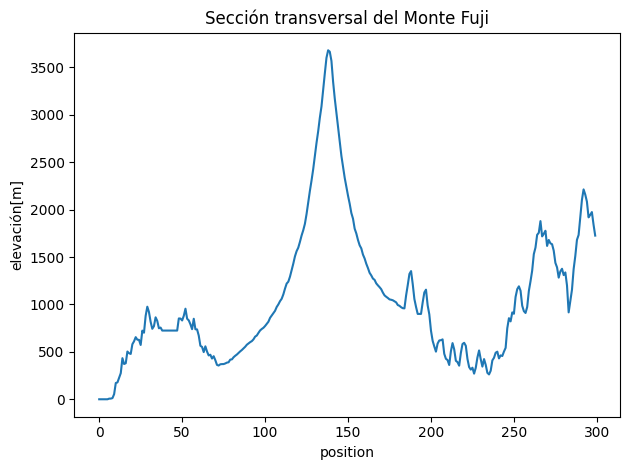

In [2]:
# Visualizacion de datos
fig, ax = plt.subplots()
ax.plot(fuji[:, 0], fuji[:,3])
ax.set_xlabel('position')
ax.set_ylabel('elevación[m]')
ax.set_title("Sección transversal del Monte Fuji")
fig.tight_layout()
plt.show()

In [3]:
# Creación de la funcion para calcular el gradiente
def gradient_calc(fuji_data, current_point):
  if current_point <= 0:
    # No se puede calcular el gradiente en el primer punto
    return 0

  current_x = fuji_data[current_point, 0] # número del punto
  current_y = fuji_data[current_point, 3] # Elevación del punto

  prev_x = fuji_data[current_point - 1, 0] # Número del punto anterior
  prev_y = fuji_data[current_point - 1, 3] # Elevación del punto anterior

  # Cálculo del gradiente (y2 - y1) / (x2 - x1)
  dx = current_x - prev_x
  dy = current_y - prev_y

  # Evitamos la división por cero
  if dx == 0:
      return 0
  return dy / dx

# Prueba
current_point = 145
gradient = gradient_calc(fuji, current_point)
print(f'Gradient at point {current_point}: {gradient}')

Gradient at point 145: -151.52999999999975


In [4]:
# Funcion para calcular el destino
def calc_nxt_point(fuji_data, current_point, alpha=0.2):

    # Calcular el gradiente en el punto actual
    gradient = gradient_calc(fuji_data, current_point)

    # Calcular el siguiente punto
    next_point_float = current_point - alpha * gradient
    next_point = round(next_point_float)

    # Asegurarse que el siguiente punto se encuentre en un rango válido
    if next_point < 0:
        next_point = 0
    elif next_point >= len(fuji_data):
        next_point = len(fuji_data) - 1

    return next_point

# Prueba
current_point = 145
next_point = calc_nxt_point(fuji, current_point)
print(f'Next point from point {current_point}: {next_point}')

Next point from point 145: 175


In [5]:
def descend_mountain(fuji_data, start_point=136, alpha=0.2, max_iterations=1000):
    # Inicializar el camino desde el start point
    path = [start_point]
    current_point = start_point

    # Descender hasta alcanzar un mínimo local o un máximo de pasos
    for _ in range(max_iterations):
        next_point = calc_nxt_point(fuji_data, current_point, alpha)
        # Si nos quedamos en un mismo punto hemos alcanzado un mínimo local
        if next_point == current_point:
            break
        # Nos movemos al siguiente punto
        current_point = next_point
        path.append(current_point)

    return path
# test
descending_route = descend_mountain(fuji)
print('Descending rount:', descending_route)


Descending rount: [136, 102, 98, 95, 93, 89, 85, 82, 79, 73, 70, 78, 77, 75]


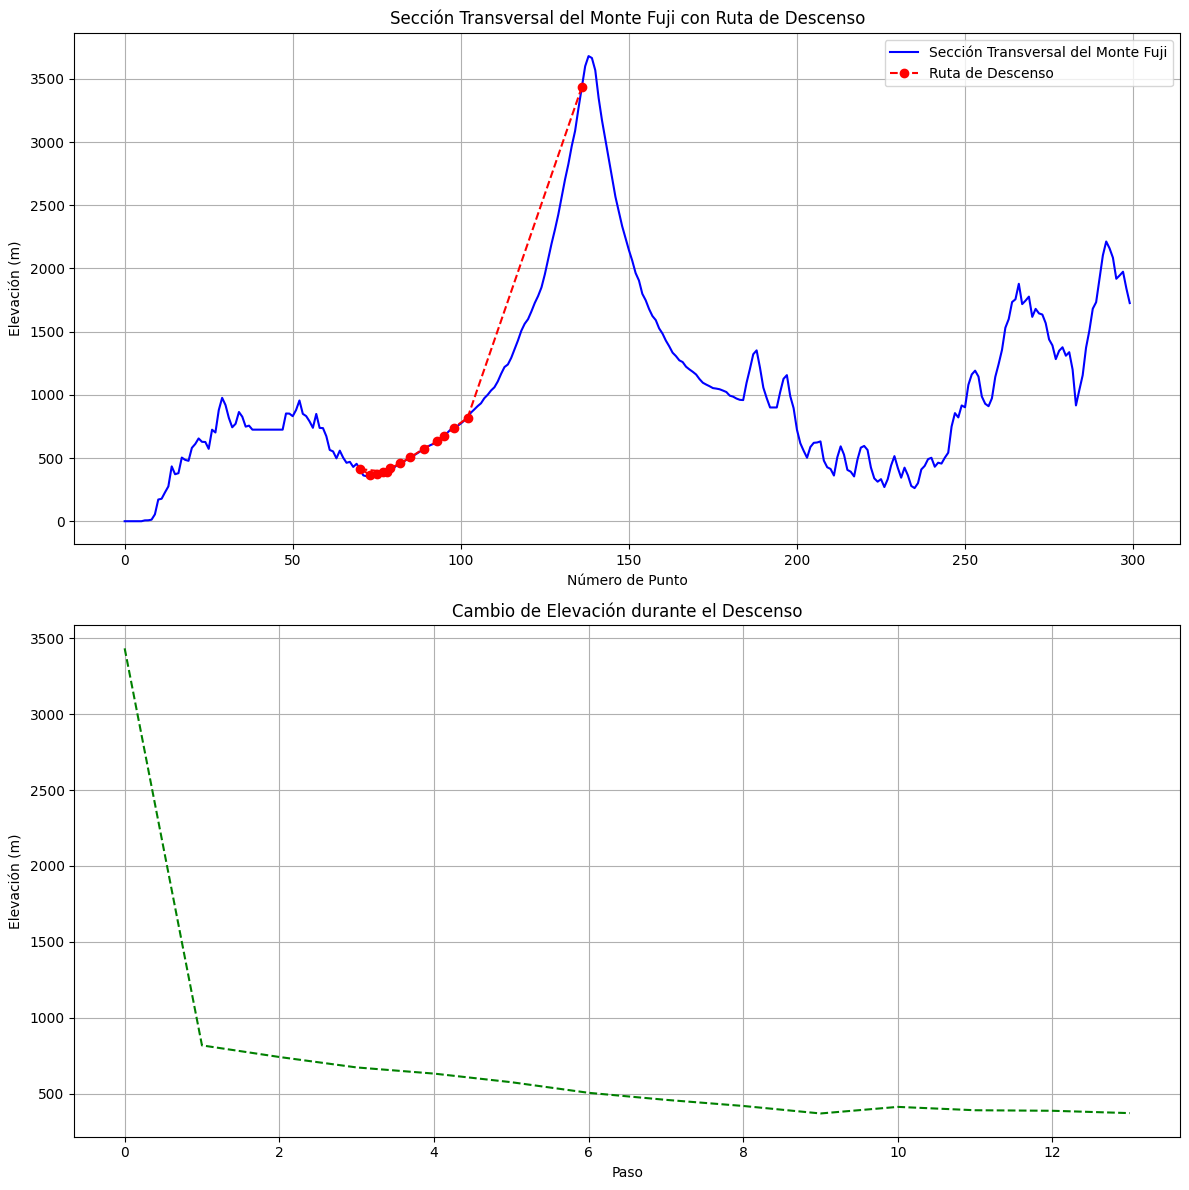

In [6]:
# Visualizacion del proceso de descenso
def visualize_descent(fuji_data, path):
  # Extraer los puntos y elevacion
  point_numbers = fuji_data[:, 0]
  elevations = fuji_data[:, 3]

  # Extrer las coordenadas de la ruta de descenso
  path_points = [fuji_data[p, 0] for p in path]
  path_elevations = [fuji_data[p, 3] for p in path]

  # Crear una figura con dos graficos
  fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

  # Plot la sección transversal con la ruta de descenso
  ax1.plot(point_numbers, elevations, 'b-', label='Sección Transversal del Monte Fuji')
  ax1.plot(path_points, path_elevations, 'ro--', label = 'Ruta de Descenso')
  ax1.set_title('Sección Transversal del Monte Fuji con Ruta de Descenso')
  ax1.set_xlabel('Número de Punto')
  ax1.set_ylabel('Elevación (m)')
  ax1.grid(True)
  ax1.legend()
  # Plot el cambio de elevación durante el descenso
  steps = list(range(len(path)))
  ax2.plot(steps, path_elevations, 'g--')
  ax2.set_title('Cambio de Elevación durante el Descenso')
  ax2.set_xlabel('Paso')
  ax2.set_ylabel('Elevación (m)')
  ax2.grid(True)

  plt.tight_layout()
  plt.show()

descent_path = descend_mountain(fuji, start_point=136, alpha=0.2)
visualize_descent(fuji, descent_path)

In [7]:
# Cambio de la variable inicial
def calc_all_descents(fuji_data, alpha=0.2):
    all_paths = {}
    initial_indices = [20, 50, 100, 136, 142, 180]

    for start_point in initial_indices:
        path = descend_mountain(fuji_data, start_point, alpha)
        all_paths[start_point] = path

    return all_paths

all_descents = calc_all_descents(fuji, alpha=0.2)
print('All descents:', all_descents)

All descents: {20: [20, 0], 50: [50, 54, 58, 80], 100: [100, 96, 90, 87, 84, 81, 77, 75], 136: [136, 102, 98, 95, 93, 89, 85, 82, 79, 73, 70, 78, 77, 75], 142: [142, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173, 176, 177, 178, 180, 186, 164, 169, 173,

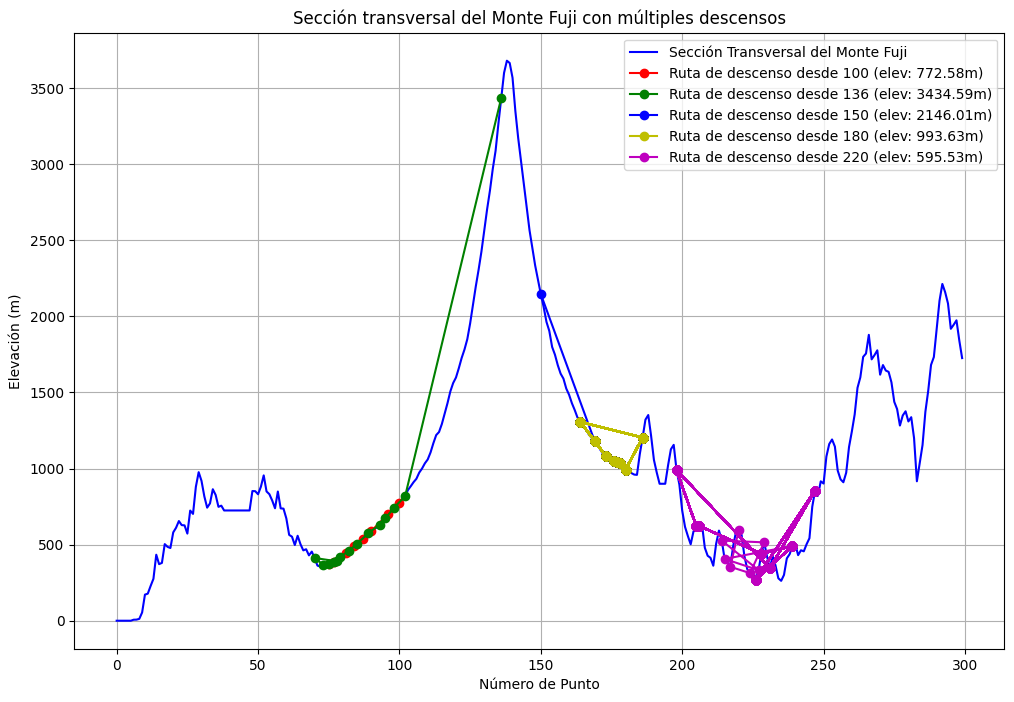

In [8]:
# Visualizacion de multiples descensos
def visualize_all_descents(fuji_data, start_points,alpha=0.2):
    # Extraer números de puntos y elevación
    point_numbers = fuji_data[:, 0]
    elevations = fuji_data[:, 3]

    # Crear la figura
    plt.figure(figsize=(12, 8))

    # Graficar la sección transversal
    plt.plot(point_numbers, elevations, 'b-', label='Sección Transversal del Monte Fuji')

    # Graficar las rutas de descenso desde diferentes puntos de partida
    colors = ['r', 'g', 'b', 'y', 'm', 'c']

    for i, start in enumerate(start_points):
      path = descend_mountain(fuji_data, start, alpha)
      path_points = [fuji_data[p, 0] for p in path]
      path_elevations = [fuji_data[p, 3] for p in path]

      color = colors[i % len(colors)]
      plt.plot(path_points, path_elevations, f'{color}o-',
               label=f'Ruta de descenso desde {start} (elev: {fuji_data[start, 3]:.2f}m)')
    plt.title('Sección transversal del Monte Fuji con múltiples descensos')
    plt.xlabel('Número de Punto')
    plt.ylabel('Elevación (m)')
    plt.grid(True)
    plt.legend()
    plt.show()
start_points = [100, 136, 150, 180, 220]
visualize_all_descents(fuji, start_points)

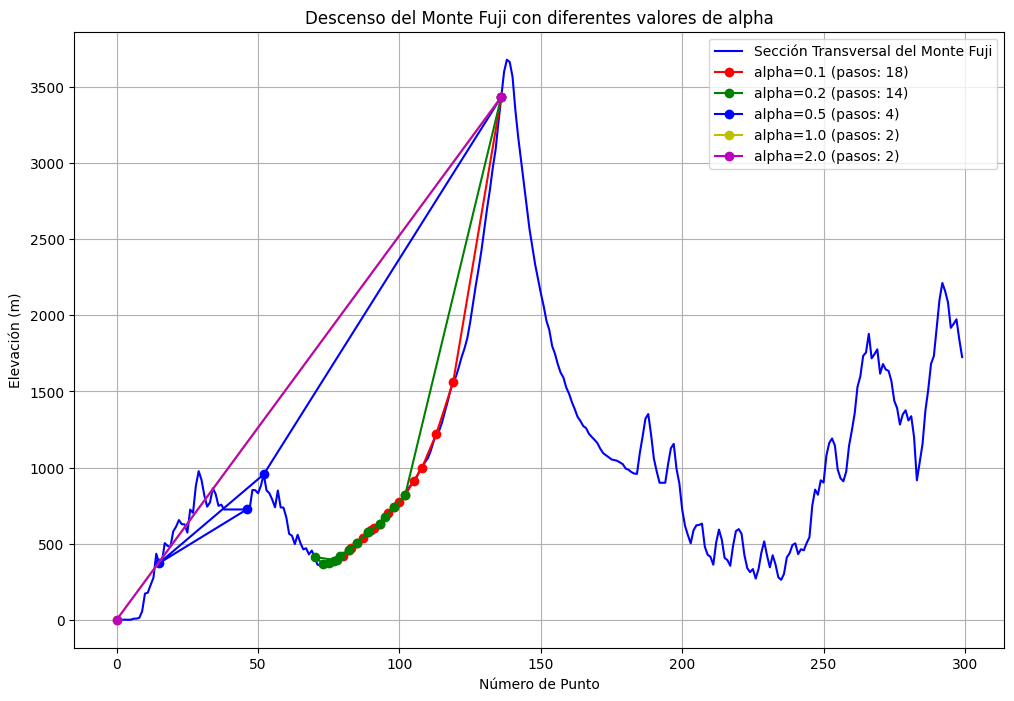

In [9]:
# Cambio de hiperparametro alpha
def visualize_alpha_effect(fuji_data, start_point=136, alphas=[0.1, 0.2, 0.5, 1.0, 2.0]):
    # Extraer los números de puntos y elevaciones
    point_numbers = fuji_data[:, 0]
    elevations = fuji_data[:, 3]

    # Crear una figura de la sección transversal
    plt.figure(figsize=(12, 8))
    plt.plot(point_numbers, elevations, 'b-', label='Sección Transversal del Monte Fuji')

    # Graficar las distintas rutas de descenso
    colors = ['r', 'g', 'b', 'y', 'm']
    for i, alpha in enumerate(alphas):
        path = descend_mountain(fuji_data, start_point, alpha)
        path_points = [fuji_data[p, 0] for p in path]
        path_elevations = [fuji_data[p, 3] for p in path]

        color = colors[i % len(colors)]
        plt.plot(path_points, path_elevations, f'{color}o-',
                 label=f'alpha={alpha} (pasos: {len(path)})')

    plt.title('Descenso del Monte Fuji con diferentes valores de alpha')
    plt.xlabel('Número de Punto')
    plt.ylabel('Elevación (m)')
    plt.grid(True)
    plt.legend()
    plt.show()
# Prueba
visualize_alpha_effect(fuji)